# 🛡️ ForgeShield
## Explainable AI & Unified Risk Analysis

**Project:** AI-Based Industrial Safety and Predictive Risk Management System

This notebook presents the explainability and decision-layer components of ForgeShield.

### Objectives
- Analyze model predictions using SHAP
- Identify important sensor and engineered features
- Demonstrate sample-level prediction explanations
- Combine failure probability and anomaly evidence
- Analyze the resulting unified machine-risk score
- Inspect the structured high-risk demonstration event

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Locate ForgeShield project root
current_path = Path.cwd().resolve()

PROJECT_ROOT = None
for path in [current_path, *current_path.parents]:
    if (path / "reports").is_dir() and (path / "src").is_dir():
        PROJECT_ROOT = path
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate ForgeShield project root.")

REPORTS_DIR = PROJECT_ROOT / "reports"

# SHAP results
shap_path = (
    REPORTS_DIR
    / "figures"
    / "explainability"
    / "global_shap_comparison.csv"
)

# Unified risk results
risk_path = (
    REPORTS_DIR
    / "integration"
    / "integrated_risk_table.csv"
)

shap_results = pd.read_csv(shap_path)
risk_results = pd.read_csv(risk_path)

print("SHAP columns:")
print(shap_results.columns.tolist())

print("\nRisk-table columns:")
print(risk_results.columns.tolist())

print("\nSHAP results:")
display(shap_results.head())

print("\nRisk results:")
display(risk_results.head())

SHAP columns:
['feature', 'mean', 'std']

Risk-table columns:
['Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Temperature Differential', 'Mechanical Power', 'Type_H', 'Type_L', 'Type_M', 'failure_probability', 'anomaly_score', 'unified_risk_score', 'risk_band', 'actual_failure']

SHAP results:


,feature,mean,std
0,Tool wear,0.973445,1.128140
1,Rotational speed,0.647263,0.699710
2,Mechanical Power,0.594908,0.819199
3,Torque,0.445813,0.567419
4,Temperature Differential,0.388929,0.374558



Risk results:


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Temperature Differential,Mechanical Power,Type_H,Type_L,Type_M,failure_probability,anomaly_score,unified_risk_score,risk_band,actual_failure
0,0.247681,-0.139294,-1.240031,2.278478,0.712410,-0.700758,2.398078,0.0,1.0,0.0,0.020027,0.442091,0.188852,Low,0
1,1.850310,1.618248,-0.116820,0.010096,0.429427,-1.300884,0.066572,0.0,1.0,0.0,0.001204,0.248804,0.100244,Low,0
2,1.249324,0.942270,0.190726,-0.240831,1.592802,-1.100842,-0.135724,0.0,1.0,0.0,0.055185,0.225953,0.123492,Low,0
3,-2.206344,-2.505215,-0.143563,-0.421499,-0.749670,0.699533,-0.588639,1.0,0.0,0.0,0.001189,0.805984,0.323107,Medium,0
4,0.247681,-0.004098,-1.153116,2.047625,-0.089376,-0.500717,2.170615,1.0,0.0,0.0,0.013196,0.754968,0.309905,Medium,0


,feature,mean,std
0,Tool wear,0.973445,1.128140
1,Rotational speed,0.647263,0.699710
2,Mechanical Power,0.594908,0.819199
3,Torque,0.445813,0.567419
4,Temperature Differential,0.388929,0.374558
5,Process temperature,0.183859,0.247774
6,Air temperature,0.171650,0.255722
7,Type_L,0.040846,0.053007
8,Type_M,0.038615,0.054801
9,Type_H,0.015171,0.025094


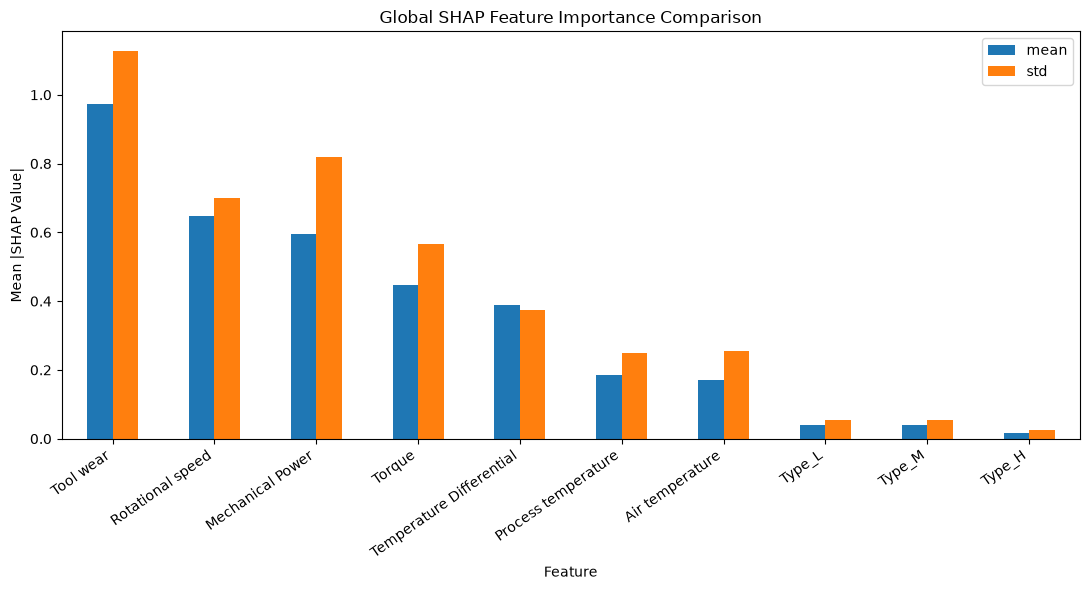

In [2]:
# Global SHAP feature-importance comparison

display(shap_results)

ax = shap_results.plot(
    x=shap_results.columns[0],
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Global SHAP Feature Importance Comparison")
ax.set_xlabel("Feature")
ax.set_ylabel("Mean |SHAP Value|")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Risk-band distribution:


,Count
Risk Band,
Low,1699
Medium,246
Critical,34
High,21


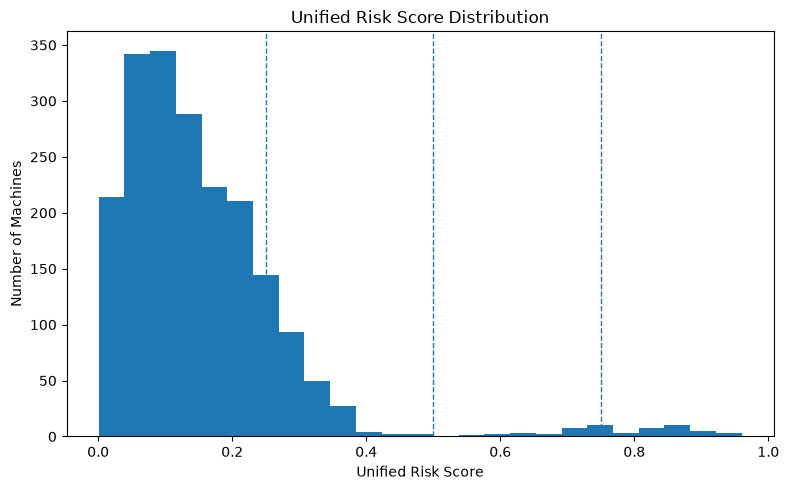

In [3]:
# Unified risk-score distribution

print("Risk-band distribution:")
display(
    risk_results["risk_band"]
    .value_counts()
    .rename_axis("Risk Band")
    .to_frame("Count")
)

plt.figure(figsize=(8, 5))

plt.hist(
    risk_results["unified_risk_score"],
    bins=25
)

plt.axvline(0.25, linestyle="--", linewidth=1)
plt.axvline(0.50, linestyle="--", linewidth=1)
plt.axvline(0.75, linestyle="--", linewidth=1)

plt.title("Unified Risk Score Distribution")
plt.xlabel("Unified Risk Score")
plt.ylabel("Number of Machines")

plt.tight_layout()
plt.show()

In [4]:
# Inspect the selected high-risk demonstration event

import json
from IPython.display import display, Markdown

event_path = (
    REPORTS_DIR
    / "integration"
    / "demo_event.json"
)

with open(event_path, "r", encoding="utf-8") as f:
    demo_event = json.load(f)

print("ForgeShield Demonstration Event")
print("=" * 50)

for key, value in demo_event.items():
    print(f"{key}: {value}")

ForgeShield Demonstration Event
machine_id: 4343
event_type: heat_dissipation_failure
risk_score: 0.960131
risk_band: Critical
failure_probability: 0.999465
anomaly_score: 0.901129
air_temperature: 301.7
process_temperature: 309.8
rotational_speed: 1284.0
torque: 68.2
tool_wear: 111.0
temperature_differential: 8.1
mechanical_power: 9170.183292
product_type: M
TWF: 0
HDF: 1
PWF: 1
OSF: 0
RNF: 0
actual_failure: 1


## Unified Risk Decision Layer

ForgeShield combines two complementary signals:

**Unified Risk = 0.60 × Failure Probability + 0.40 × Anomaly Score**

The resulting score is mapped to four research-oriented risk bands:

| Unified Risk | Risk Band |
|---:|---|
| `< 0.25` | Low |
| `0.25 – < 0.50` | Medium |
| `0.50 – < 0.75` | High |
| `≥ 0.75` | Critical |

The unified score is a **research decision layer** rather than a certified industrial safety metric.

## Explainability & Risk Summary

SHAP analysis provides feature-level interpretation of machine-failure predictions, helping connect model outputs with measurable machine conditions.

The unified risk layer combines:

- **Supervised failure probability**
- **Unsupervised anomaly evidence**

This produces a single machine-level risk signal for downstream dashboard visualization and safety intelligence.

The selected demonstration event represents a high-risk machine state with elevated model-predicted failure probability and anomaly evidence. This structured event is passed to the downstream incident-intelligence and RAG components.

### Research takeaway

The ForgeShield architecture does not treat prediction as the final output. Instead, it extends the prediction into an interpretable decision layer that can support evidence-grounded incident analysis and safety-oriented human review.